In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ai_adoption_500.csv to ai_adoption_500 (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

# Display plots inside notebook
%matplotlib inline

In [ ]:
df = pd.read_csv('ai_adoption_500.csv')

df.head()

,Organization_ID,Industry,Company_Size,Employee_Count,AI_Tool,Adoption_Year,Monthly_AI_Users,Productivity_Gain,Satisfaction_Score,AI_Investment,Cost_Savings,Adoption_Level
0,1001,Healthcare,Large,2130,Claude,2024,497,12.5,8.0,241479.93,289777.55,High
1,1002,Education,Small,137,Midjourney,2023,21,14.6,7.5,18149.16,25451.68,Low
2,1003,Healthcare,Medium,931,ChatGPT,2025,158,12.3,8.5,110087.21,196864.73,Medium
3,1004,Finance,Large,1646,ChatGPT,2022,633,34.1,9.2,181819.43,212432.45,High
4,1005,Education,Medium,704,Gemini,2025,107,19.8,7.1,109497.44,153034.62,Medium


In [ ]:
df.shape

(500, 12)

In [ ]:
df.columns

Index(['Organization_ID', 'Industry', 'Company_Size', 'Employee_Count',
       'AI_Tool', 'Adoption_Year', 'Monthly_AI_Users', 'Productivity_Gain',
       'Satisfaction_Score', 'AI_Investment', 'Cost_Savings',
       'Adoption_Level'],
      dtype='object')

In [ ]:
df.describe()


,Organization_ID,Employee_Count,Adoption_Year,Monthly_AI_Users,Productivity_Gain,Satisfaction_Score,AI_Investment,Cost_Savings
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,1250.500000,947.438000,2023.628000,233.440000,22.468600,8.138200,124390.561560,1.809898e+05
std,144.481833,1190.926235,0.989735,332.334999,7.298076,0.925437,160724.305684,2.365487e+05
min,1001.000000,50.000000,2022.000000,5.000000,10.000000,6.500000,4818.960000,5.731100e+03
25%,1125.750000,176.500000,2023.000000,40.750000,16.200000,7.400000,23252.445000,3.339125e+04
50%,1250.500000,487.500000,2024.000000,105.500000,22.700000,8.100000,64236.715000,8.848140e+04
75%,1375.250000,972.750000,2024.000000,242.250000,28.725000,8.900000,134090.622500,1.963759e+05
max,1500.000000,4979.000000,2025.000000,1829.000000,34.800000,9.800000,794310.790000,1.298901e+06


In [ ]:
df.isnull().sum()

,0
Organization_ID,0
Industry,0
Company_Size,0
Employee_Count,0
AI_Tool,0
Adoption_Year,0
Monthly_AI_Users,0
Productivity_Gain,0
Satisfaction_Score,0
AI_Investment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(500, 12)

**Phase 1: Data Understanding**

Number of Organizations

In [ ]:
df['Organization_ID'].nunique()

500

**Most Commonly Used AI Tools**

In [ ]:
df['AI_Tool'].value_counts()

,count
AI_Tool,
ChatGPT,190
GitHub Copilot,110
Gemini,60
Claude,53
Midjourney,44
Power BI AI,43


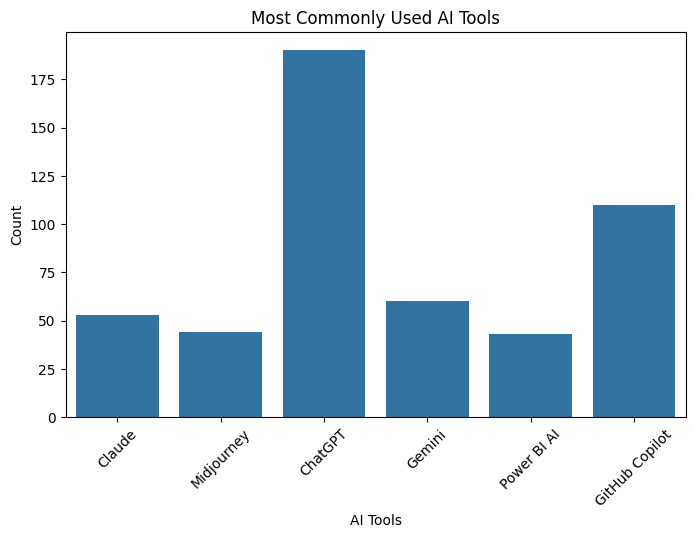

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='AI_Tool',
    data=df
)

plt.title('Most Commonly Used AI Tools')
plt.xlabel('AI Tools')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

**Industry-wise Adoption Distribution**

In [ ]:
df['Industry'].value_counts()

,count
Industry,
IT,124
Finance,89
Manufacturing,84
Healthcare,82
Retail,80
Education,41


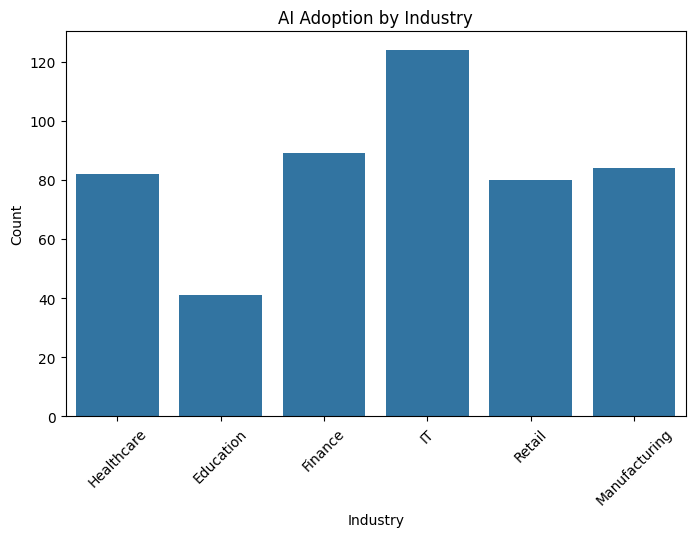

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Industry',
    data=df
)

plt.title('AI Adoption by Industry')
plt.xlabel('Industry')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

**Phase 2: Descriptive Statistics**

Mean Productivity Gain



In [ ]:
mean_productivity = df['Productivity_Gain'].mean()

print("Mean Productivity Gain:", mean_productivity)

Mean Productivity Gain: 22.4686


Median Productivity Gain

In [ ]:
median_productivity = df['Productivity_Gain'].median()

print("Median Productivity Gain:", median_productivity)

Median Productivity Gain: 22.7


Standard Deviation

In [ ]:
std_productivity = df['Productivity_Gain'].std()

print("Standard Deviation:", std_productivity)

Standard Deviation: 7.298076313368577


Quartiles

In [ ]:
df['Productivity_Gain'].quantile(
    [0.25, 0.50, 0.75]
)

,Productivity_Gain
0.25,16.200
0.50,22.700
0.75,28.725


Percentiles

In [ ]:
np.percentile(
    df['Productivity_Gain'],
    [10, 25, 50, 75, 90]
)

array([12.19 , 16.2  , 22.7  , 28.725, 32.3  ])

Company Size Distribution

In [ ]:
df['Company_Size'].value_counts()

,count
Company_Size,
Medium,204
Small,179
Large,117


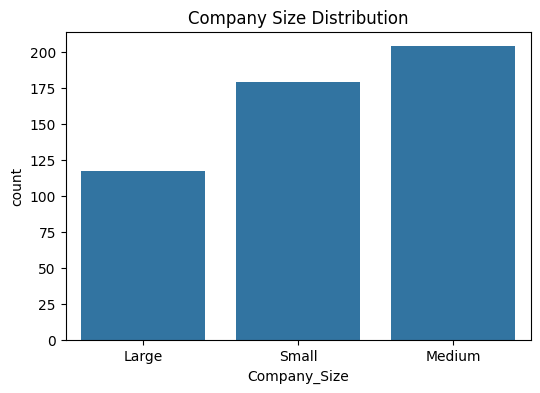

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Company_Size',
    data=df
)

plt.title('Company Size Distribution')

plt.show()

**Phase 3: Trend Investigation**

Industry vs AI Adoption

In [ ]:
industry_usage = df.groupby(
    'Industry'
)['Monthly_AI_Users'].mean()

industry_usage

,Monthly_AI_Users
Industry,
Education,321.000000
Finance,221.932584
Healthcare,255.231707
IT,207.032258
Manufacturing,220.892857
Retail,233.137500


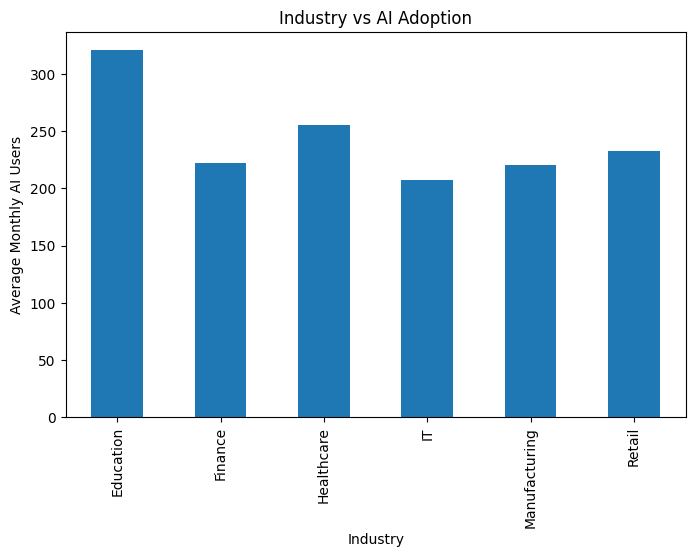

In [ ]:
industry_usage.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Industry vs AI Adoption'
)

plt.ylabel(
    'Average Monthly AI Users'
)

plt.show()

Company Size vs Adoption

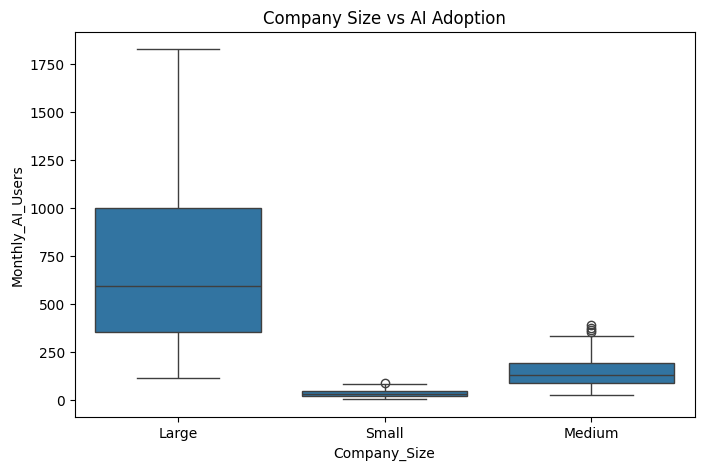

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Company_Size',
    y='Monthly_AI_Users',
    data=df
)

plt.title(
    'Company Size vs AI Adoption'
)

plt.show()

AI Tool vs Satisfaction

In [ ]:
tool_satisfaction = df.groupby(
    'AI_Tool'
)['Satisfaction_Score'].mean()

tool_satisfaction

,Satisfaction_Score
AI_Tool,
ChatGPT,8.192632
Claude,8.066038
Gemini,8.058333
GitHub Copilot,8.130909
Midjourney,7.852273
Power BI AI,8.409302


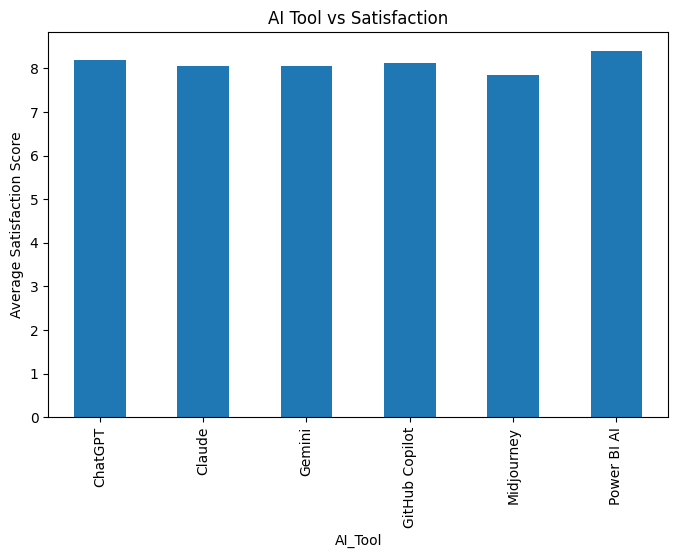

In [ ]:
tool_satisfaction.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'AI Tool vs Satisfaction'
)

plt.ylabel(
    'Average Satisfaction Score'
)

plt.show()

Adoption Year vs Growth

In [ ]:
growth = df.groupby(
    'Adoption_Year'
).size()

growth

,0
Adoption_Year,
2022,76
2023,144
2024,170
2025,110


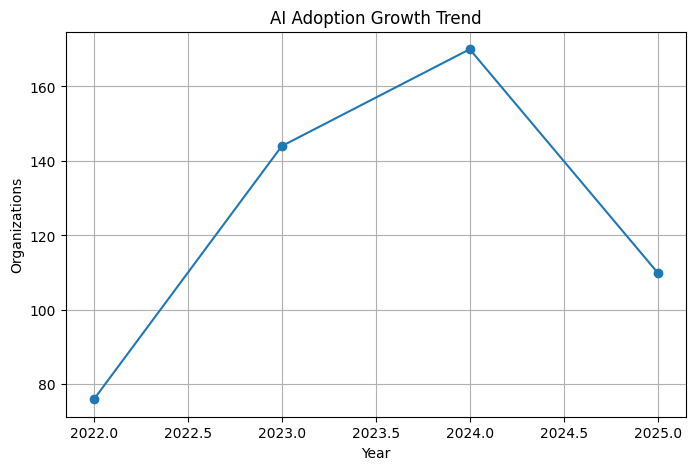

In [ ]:
growth.plot(
    marker='o',
    figsize=(8,5)
)

plt.title(
    'AI Adoption Growth Trend'
)

plt.xlabel('Year')

plt.ylabel(
    'Organizations'
)

plt.grid()

plt.show()

Employee Count vs AI Usage

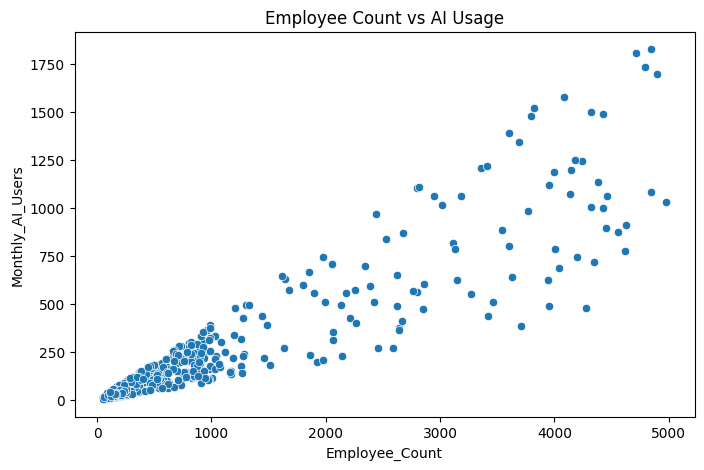

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Employee_Count',
    y='Monthly_AI_Users',
    data=df
)

plt.title(
    'Employee Count vs AI Usage'
)

plt.show()

**Phase 4: Correlation Analysis**

Create Correlation Matrix


In [ ]:
numeric_data = df[[
    'Employee_Count',
    'Monthly_AI_Users',
    'Productivity_Gain',
    'AI_Investment',
    'Cost_Savings',
    'Satisfaction_Score'
]]

corr_matrix = numeric_data.corr()

corr_matrix

,Employee_Count,Monthly_AI_Users,Productivity_Gain,AI_Investment,Cost_Savings,Satisfaction_Score
Employee_Count,1.000000,0.916372,-0.013791,0.963764,0.943654,-0.056574
Monthly_AI_Users,0.916372,1.000000,-0.034811,0.893244,0.871320,-0.059629
Productivity_Gain,-0.013791,-0.034811,1.000000,-0.009511,-0.026828,0.032906
AI_Investment,0.963764,0.893244,-0.009511,1.000000,0.984091,-0.050963
Cost_Savings,0.943654,0.871320,-0.026828,0.984091,1.000000,-0.037128
Satisfaction_Score,-0.056574,-0.059629,0.032906,-0.050963,-0.037128,1.000000


Correlation Heatmap

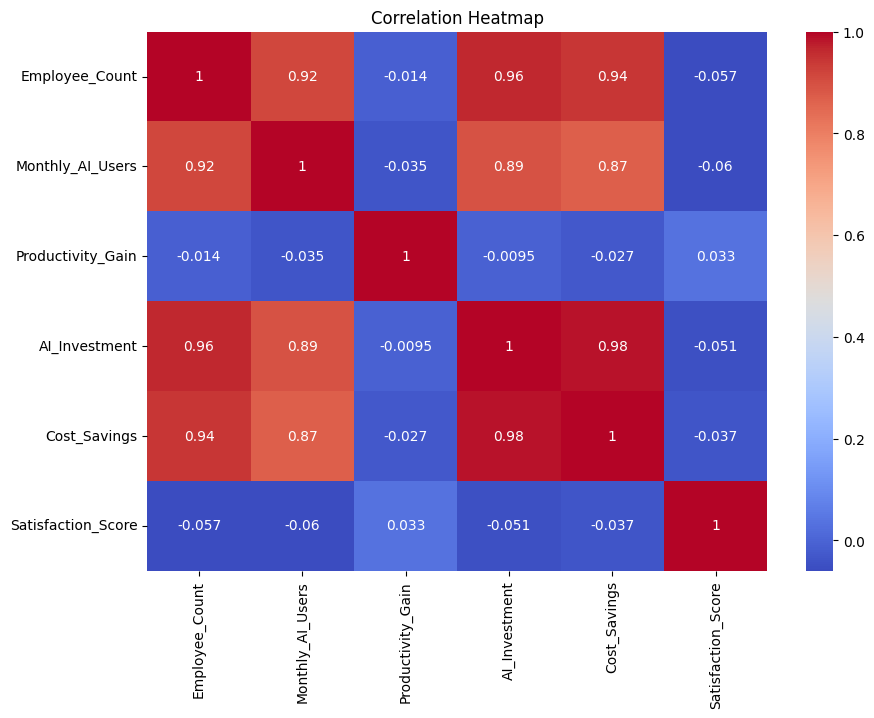

In [ ]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

Adoption vs Productivity

In [ ]:
corr1 = df['Monthly_AI_Users'].corr(
    df['Productivity_Gain']
)

print(corr1)

-0.034811178045660446


Employee Count vs Adoption

In [ ]:
corr2 = df['Employee_Count'].corr(
    df['Monthly_AI_Users']
)

print(corr2)

0.9163715200722764


Investment vs Savings

In [ ]:
corr3 = df['AI_Investment'].corr(
    df['Cost_Savings']
)

print(corr3)

0.984090563616529


**Phase 5: Hypothesis Testing**

**Define Hypotheses**

Null Hypothesis (H₀)

Company size has no impact on AI adoption.

Alternative Hypothesis (H₁)

Company size significantly impacts AI adoption.

Separate Groups

In [ ]:
small = df[
    df['Company_Size'] == 'Small'
]['Monthly_AI_Users']

medium = df[
    df['Company_Size'] == 'Medium'
]['Monthly_AI_Users']

large = df[
    df['Company_Size'] == 'Large'
]['Monthly_AI_Users']

Perform ANOVA Test

In [ ]:
F_statistic, p_value = f_oneway(
    small,
    medium,
    large
)

print("F Statistic:", F_statistic)

print("P-value:", p_value)

F Statistic: 368.50158616850945
P-value: 7.119802917300987e-99


Interpret Results

In [ ]:
if p_value < 0.05:
    print(
        "Reject Null Hypothesis"
    )

    print(
        "Company size significantly impacts AI adoption"
    )

else:
    print(
        "Fail to Reject Null Hypothesis"
    )

    print(
        "Company size does not significantly impact AI adoption"
    )

Reject Null Hypothesis
Company size significantly impacts AI adoption


**Phase 6: Organization Segmentation**


Create Segments

In [ ]:
conditions = [

(df['Productivity_Gain'] > 25) &
(df['Cost_Savings'] >
 df['AI_Investment']),

(df['Monthly_AI_Users'] > 100),

(df['Monthly_AI_Users'] < 50)

]

choices = [

'AI Leaders',

'Early Adopters',

'Slow Adopters'

]

df['Segment'] = np.select(
    conditions,
    choices,
    default='Others'
)

Segment Counts

In [ ]:
df['Segment'].value_counts()

,count
Segment,
AI Leaders,202
Early Adopters,147
Slow Adopters,100
Others,51


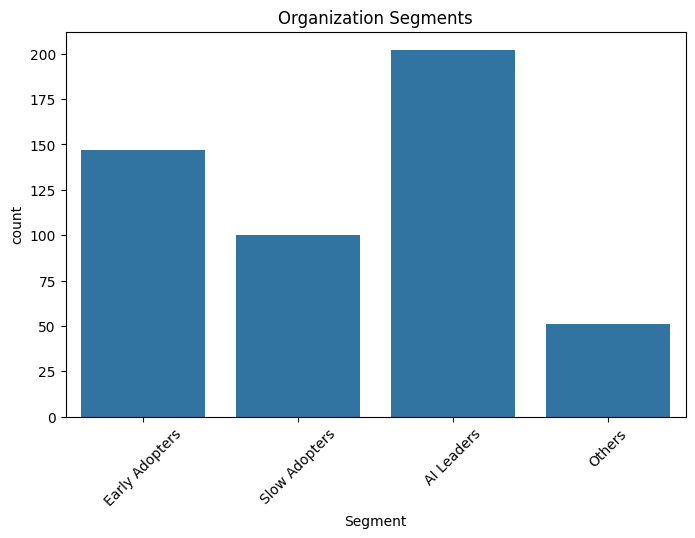

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=df
)

plt.title(
    'Organization Segments'
)

plt.xticks(rotation=45)

plt.show()

**Phase 7: Business Insights**

1. Which AI tools show rapid growth?

In [ ]:
df['AI_Tool'].value_counts()

,count
AI_Tool,
ChatGPT,190
GitHub Copilot,110
Gemini,60
Claude,53
Midjourney,44
Power BI AI,43


2. Which industries lead adoption?

industry_usage

3. Does AI improve productivity?

corr1

4. Do larger organizations adopt AI faster?

ANOVA results.

5. Which organizations are AI Leaders?

In [ ]:
df['Segment'].value_counts()

,count
Segment,
AI Leaders,202
Early Adopters,147
Slow Adopters,100
Others,51
